In [1]:
# read with pandas

import pandas as pd


cols = ["[RP2006]", "F[OIII]", "e_F[OIII]", "_RA", "_DE"]
tablea1 = pd.read_csv("tablea1.csv", sep=",")
tablea2 = pd.read_csv("tablea2.csv", sep=",")

tablea2.columns
coords = pd.concat([tablea1[cols], tablea2[cols]], ignore_index=False)

coords

FileNotFoundError: [Errno 2] No such file or directory: 'tablea1.csv'

In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

snr = SkyCoord("05h47m50s", "-70d24m45s", frame="icrs")
pnes = SkyCoord(coords["_RA"].values * u.deg, coords["_DE"].values * u.deg, frame="icrs")

pnes

<SkyCoord (ICRS): (ra, dec) in deg
    [(71.82407194, -69.30074944), (72.21514556, -69.163105  ),
     (72.27235778, -68.40358583), (72.39023056, -69.19919833),
     (72.60416   , -64.20095528), (72.35379194, -69.21930861),
     (72.34573583, -69.25760778), (72.34792583, -69.130385  ),
     (72.45687528, -69.41619306), (72.51770028, -67.66633472),
     (72.92683139, -66.91790472), (73.02631333, -66.92420167),
     (73.04591111, -66.90790278), (72.99120806, -68.41026056),
     (73.03233361, -69.34664139), (72.94545417, -69.39401861),
     (73.04940333, -69.34533194), (73.14493556, -67.29339167),
     (73.295915  , -66.90851222), (73.25619194, -68.05285611),
     (73.14831167, -68.91297806), (73.1899125 , -69.2176425 ),
     (73.26970944, -69.23773833), (73.40863333, -68.82057333),
     (72.958715  , -70.76865333), (73.36623222, -67.05412833),
     (73.38563722, -67.00365972), (73.37404278, -67.39030028),
     (73.30979139, -70.60416278), (73.59456028, -69.18813944),
     (73.48131972, -

In [ ]:
sep = snr.separation(pnes)

fov = coords[sep < 10 * u.arcmin]

fov

,recno,DEM,m_DEM,Name,RA1950,DE1950,Maj,Min,Int,Comm,Radio,_RA_icrs,_DE_icrs
238,239,213,,,82.312500,-70.376944,2.5,2.0,vf,,,82.179976,-70.339351
240,241,215,,,82.500000,-69.850000,3.0,3.0,f,diffuse ring,,82.389005,-69.813361
241,242,216,,,82.647917,-69.788333,0.7,0.7,f+b,diffuse,,82.539143,-69.752413
243,244,218,,,82.750833,-70.166389,10.0,9.0,fb,diffuse filaments,,82.626367,-70.130927
246,247,221,,"N206A,B",82.825000,-71.100000,25.0,18.0,f+b,complex; loops and filaments (contains SNR),MC54; 6.6'x4.9'; ALPHA=+0.02,82.659550,-71.064797
...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,353,324,,,87.299583,-69.857222,1.0,0.8,f,diffuse,,87.182110,-69.843796
353,354,325,,,87.366667,-70.007778,1.3,1.3,b,diffuse shell,,87.242941,-69.994662
354,355,326,,N180,87.450000,-70.133333,12.0,8.0,fb,shell surrounding No 323,,87.320973,-70.120609
355,356,327,,,87.459167,-69.331944,5.0,4.0,vf,diffuse,,87.362544,-69.319344


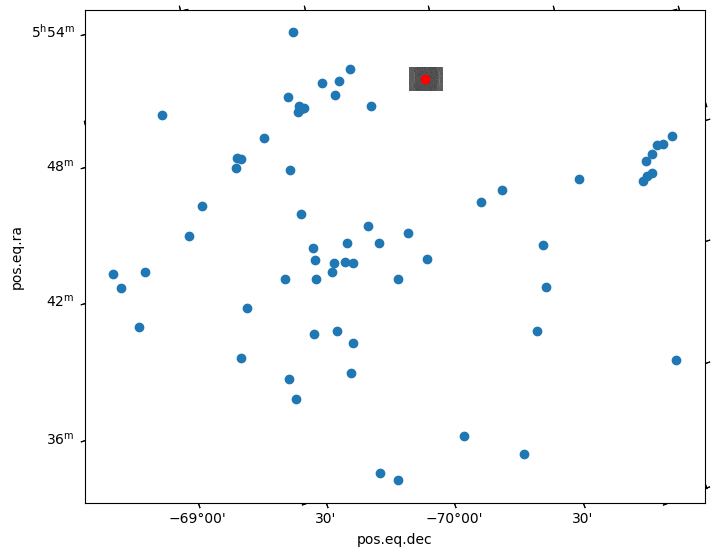

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("test_sub6.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["_RA"].values *u.deg, fov["_DE"].values *u.deg, transform=ax.get_transform("world"))

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))

/Users/markpirgalin/anaconda3/lib/python3.11/site-packages/astropy/wcs/wcs.py:805: FITSFixedWarning: 'datfix' made the change 'Set DATE-OBS to '2020-11-12T03:31:35.772' from MJD-OBS'.
  warnings.warn(


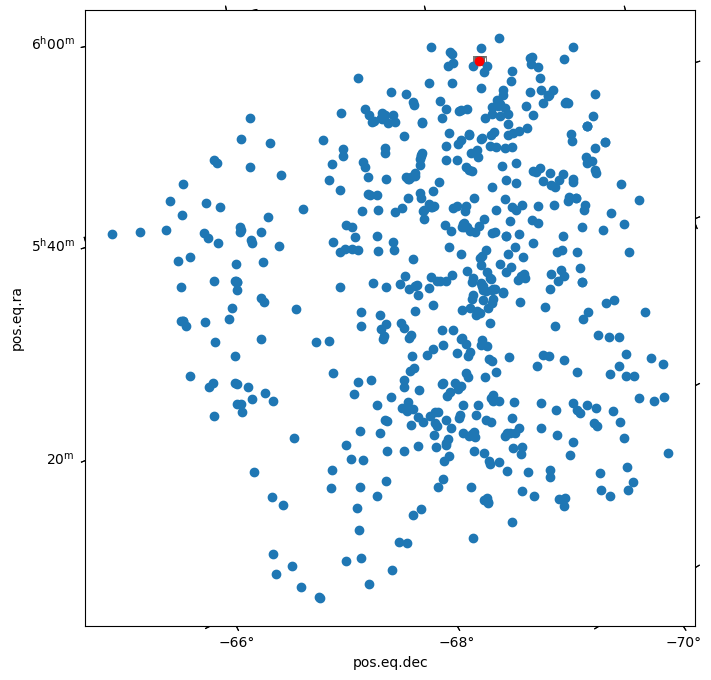

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("test_sub3.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)

fov = coords

ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["_RA"].values *u.deg, fov["_DE"].values *u.deg, transform=ax.get_transform("world"))

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))

In [ ]:
# read with pandas

import pandas as pd


# cols = ["[RP2006]", "F[OIII]", "e_F[OIII]", "_RA", "_DE"]
table = pd.read_csv("reid.csv", sep=",")

# table = table.rename(columns={
#     "RAJ2000": "_RA",
#     "DEJ2000": "_DE"
# })

table

,Name,Umag,Bmag,n_Bmag,Vmag,Imag,Jmag,n_Jmag,Hmag,n_Hmag,...,n_[4_5],[5_8],n_[5_8],[8_0],n_[8_0],[24],n_[24],SimbadName,_RA,_DE
0,MG 74,NaN,NaN,,NaN,NaN,17.666,*,NaN,,...,,NaN,,NaN,,NaN,,MGPN LMC74,85.22875,-74.68833
1,SMP 79,NaN,NaN,,NaN,NaN,15.888,,15.518,,...,,NaN,,NaN,,NaN,,SMP LMC 79,83.53604,-74.33531
2,SMP 81,NaN,NaN,,NaN,NaN,15.990,*,16.032,,...,,NaN,,NaN,,NaN,,SMP LMC 81,83.83683,-73.92508
3,RP4673,NaN,NaN,,NaN,NaN,NaN,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 4673,82.42904,-72.91558
4,MG 61,NaN,NaN,,NaN,NaN,NaN,,NaN,,...,,NaN,,13.890,,8.755,,MGPN LMC61,83.30583,-72.61306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,RP3876,NaN,21.174,,20.523,20.341,NaN,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 3876,NaN,NaN
601,RP3886,NaN,20.314,,19.974,19.543,19.240,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 3886,NaN,NaN
602,RP3923,NaN,23.024,,22.138,NaN,NaN,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 3923,NaN,NaN
603,RP4388,NaN,20.795,,20.176,NaN,18.490,,18.120,,...,,14.416,,12.926,,NaN,,[RP2006] 4388,NaN,NaN


In [ ]:
pnes = SkyCoord(table["_RA"].values * u.deg, table["_DE"].values * u.deg, frame="icrs")
sep = snr.separation(pnes)

fov = table[sep < 10 * u.arcmin]

fov

,Name,Umag,Bmag,n_Bmag,Vmag,Imag,Jmag,n_Jmag,Hmag,n_Hmag,...,n_[4_5],[5_8],n_[5_8],[8_0],n_[8_0],[24],n_[24],SimbadName,_RA,_DE
159,RP103,19.725,19.995,,19.914,19.620,18.900,,NaN,,...,,NaN,,NaN,,NaN,,[RP2006] 103,86.75637,-70.47847
160,RP102,19.418,19.112,,18.113,17.116,16.395,*,15.508,,...,,15.17,,NaN,,NaN,,[RP2006] 102,87.33442,-70.46939
161,RP122,19.276,19.462,,19.245,18.738,17.140,,17.020,,...,,NaN,,NaN,,NaN,,[RP2006] 122,86.86958,-70.33775
191,RP99,19.979,19.639,,18.594,17.799,17.190,*,16.790,,...,,NaN,,NaN,,NaN,,[RP2006] 99,86.59979,-70.43217


/Users/markpirgalin/anaconda3/lib/python3.11/site-packages/astropy/wcs/wcs.py:805: FITSFixedWarning: 'datfix' made the change 'Set DATE-OBS to '2020-11-12T03:31:35.772' from MJD-OBS'.
  warnings.warn(


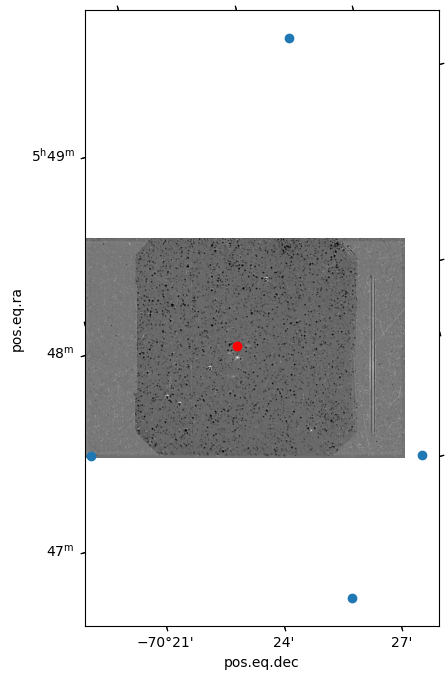

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

image = fits.open("images/csi.fits")[0].data
wcs_hdul = fits.open("images/SNR_OIII.fits")

wcs = WCS(wcs_hdul["SCI"].header)

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs)


fov = fov


ax.imshow(image, origin="lower", cmap="gray", vmin=np.percentile(image,1), vmax=np.percentile(image,99.5))

ax.scatter(fov["_RA"].values *u.deg, fov["_DE"].values *u.deg, transform=ax.get_transform("world"))

ax.scatter(snr.ra, snr.dec, color="r", transform=ax.get_transform("world"))